# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (64D, 500 Epochs) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle


from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    v_measure_score
)

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
n_inits = 10000  # Must match 6a
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{target_dim}d.pkl"

# Output directories
plots_dir = "./plots/clustering_plots/"
results_dir = "./clustering_results/"
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (500 EPOCH MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

Creating 8 clusters from 100D embeddings (500 EPOCH MEDIAN RUN)
Random seed: 20210321
n_inits: 10000


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (500 EPOCH MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...


PCA embeddings: (188880, 100)
Explained variance: 0.984

Loading stability checkpoint from: ../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_100d.pkl


Loaded 10 runs from stability checkpoint

Median RMSE: 0.7931%
Median run index: 5 (RMSE = 0.7925%)

AE embeddings (median run): (188880, 100)

Loading OAC classifications...


OAC: (188880, 1)
OAC Supergroups: 8 unique groups


## K-Means Clustering

In [4]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{results_dir}/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{results_dir}/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{results_dir}/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)
kmeans_pca = joblib.load(pca_model_file)
kmeans_ae = joblib.load(ae_model_file)

pca_clusters = clusters_df['pca_cluster'].values
ae_clusters = clusters_df['ae_cluster'].values

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans PCA - Inertia: {kmeans_pca.inertia_:.2f}")
print(f"KMeans AE  - Inertia: {kmeans_ae.inertia_:.2f}")

print("\nCluster distributions:")
print("\nPCA clusters:")
print(clusters_df['pca_cluster'].value_counts().sort_index())
print("\nAE clusters:")
print(clusters_df['ae_cluster'].value_counts().sort_index())

Loading clustering results from ./clustering_results//cluster_assignments_100d_k8_n10000.csv...
Loaded 188880 cluster assignments
KMeans PCA - Inertia: 219351.76
KMeans AE  - Inertia: 137297.43

Cluster distributions:

PCA clusters:
pca_cluster
0    27632
1    14330
2    26119
3    15566
4    12093
5    44631
6    30807
7    17702
Name: count, dtype: int64

AE clusters:
ae_cluster
0    25001
1    13144
2    14285
3    23120
4    42422
5    16034
6    22528
7    32346
Name: count, dtype: int64


## Cluster Quality Metrics

Evaluating cluster quality using multiple metrics:
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (-1 to 1, higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance (higher is better)

In [5]:
print("Computing cluster quality metrics...\n")

# WSSC (Within-cluster Sum of Squares) - already computed by KMeans
print("Within-cluster Sum of Squares (WSSC / Inertia - lower is better):")
wssc_pca = kmeans_pca.inertia_
wssc_ae = kmeans_ae.inertia_
print(f"  PCA:  {wssc_pca:.2f}")
print(f"  AE:   {wssc_ae:.2f}")
print(f"  Difference: {wssc_ae - wssc_pca:+.2f}")

# For silhouette scores, use a sample to speed up computation
# (Silhouette is O(n²) in memory and computation)
sample_size = 10000  # Use 10k samples instead of 188k for speed
print(f"\nUsing {sample_size:,} sample for silhouette computation (full dataset: {len(pca_latent_df):,})")

# Create stratified sample (proportional from each cluster)
np.random.seed(random_seed)
pca_sample_idx = []
ae_sample_idx = []

for i in range(n_clusters):
    # PCA samples
    pca_cluster_idx = np.where(pca_clusters == i)[0]
    pca_n_sample = max(int(len(pca_cluster_idx) * sample_size / len(pca_clusters)), 10)
    pca_sample_idx.extend(np.random.choice(pca_cluster_idx, size=min(pca_n_sample, len(pca_cluster_idx)), replace=False))
    
    # AE samples
    ae_cluster_idx = np.where(ae_clusters == i)[0]
    ae_n_sample = max(int(len(ae_cluster_idx) * sample_size / len(ae_clusters)), 10)
    ae_sample_idx.extend(np.random.choice(ae_cluster_idx, size=min(ae_n_sample, len(ae_cluster_idx)), replace=False))

pca_sample_idx = np.array(pca_sample_idx)
ae_sample_idx = np.array(ae_sample_idx)

# Silhouette scores (on sample)
print("\nSilhouette Scores (sampled):")
silhouette_pca = silhouette_score(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae = silhouette_score(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])
print(f"  PCA:  {silhouette_pca:.4f}")
print(f"  AE:   {silhouette_ae:.4f}")
print(f"  Difference: {silhouette_ae - silhouette_pca:+.4f}")

# Davies-Bouldin Index (lower is better) - FAST, use full data
print("\nDavies-Bouldin Index (lower is better):")
db_pca = davies_bouldin_score(pca_latent_df, pca_clusters)
db_ae = davies_bouldin_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {db_pca:.4f}")
print(f"  AE:   {db_ae:.4f}")
print(f"  Difference: {db_ae - db_pca:+.4f}")

# Calinski-Harabasz Score (higher is better) - FAST, use full data
print("\nCalinski-Harabasz Score (higher is better):")
ch_pca = calinski_harabasz_score(pca_latent_df, pca_clusters)
ch_ae = calinski_harabasz_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {ch_pca:.2f}")
print(f"  AE:   {ch_ae:.2f}")
print(f"  Difference: {ch_ae - ch_pca:+.2f}")

# Per-cluster silhouette scores (on sample)
print("\nPer-cluster silhouette scores (sampled):")
silhouette_pca_samples = silhouette_samples(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae_samples = silhouette_samples(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])

print("\nPCA:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_pca_samples[pca_clusters[pca_sample_idx] == i].mean()
    cluster_size = (pca_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

print("\nAE:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_ae_samples[ae_clusters[ae_sample_idx] == i].mean()
    cluster_size = (ae_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

# Store for comparison
quality_metrics = pd.DataFrame({
    'Metric': ['WSSC/Inertia', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'PCA': [wssc_pca, silhouette_pca, db_pca, ch_pca],
    'AE': [wssc_ae, silhouette_ae, db_ae, ch_ae],
    'Better': ['Lower', 'Higher', 'Lower', 'Higher']
})
quality_metrics['Winner'] = quality_metrics.apply(
    lambda row: 'AE' if (row['Better'] == 'Higher' and row['AE'] > row['PCA']) or 
                        (row['Better'] == 'Lower' and row['AE'] < row['PCA']) else 'PCA',
    axis=1
)

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(quality_metrics.to_string(index=False))

# Save results
quality_metrics.to_csv(f"{results_dir}/quality_metrics_{target_dim}d.csv", index=False)

# Save sample indices and silhouette samples for plotting
np.savez(f"{results_dir}/silhouette_data_{target_dim}d.npz",
         pca_sample_idx=pca_sample_idx,
         ae_sample_idx=ae_sample_idx,
         silhouette_pca_samples=silhouette_pca_samples,
         silhouette_ae_samples=silhouette_ae_samples,
         pca_clusters_sampled=pca_clusters[pca_sample_idx],
         ae_clusters_sampled=ae_clusters[ae_sample_idx])

print(f"\n✓ Saved quality metrics and silhouette data to {results_dir}")

Computing cluster quality metrics...

Within-cluster Sum of Squares (WSSC / Inertia - lower is better):
  PCA:  219351.76
  AE:   137297.43
  Difference: -82054.33

Using 10,000 sample for silhouette computation (full dataset: 188,880)

Silhouette Scores (sampled):


  PCA:  0.1251
  AE:   0.1115
  Difference: -0.0135

Davies-Bouldin Index (lower is better):


  PCA:  1.8923
  AE:   2.0005
  Difference: +0.1083

Calinski-Harabasz Score (higher is better):


  PCA:  26125.50
  AE:   27293.32
  Difference: +1167.82

Per-cluster silhouette scores (sampled):



PCA:
  Cluster 0: 0.1532 (n=27,632)
  Cluster 1: 0.1476 (n=14,330)
  Cluster 2: 0.0593 (n=26,119)
  Cluster 3: 0.0902 (n=15,566)
  Cluster 4: 0.2376 (n=12,093)
  Cluster 5: 0.1385 (n=44,631)
  Cluster 6: 0.1165 (n=30,807)
  Cluster 7: 0.0953 (n=17,702)

AE:
  Cluster 0: 0.1401 (n=25,001)
  Cluster 1: 0.1207 (n=13,144)
  Cluster 2: 0.0759 (n=14,285)
  Cluster 3: 0.1046 (n=23,120)
  Cluster 4: 0.1358 (n=42,422)
  Cluster 5: 0.0836 (n=16,034)
  Cluster 6: 0.0717 (n=22,528)
  Cluster 7: 0.1163 (n=32,346)

SUMMARY
           Metric           PCA            AE Better Winner
     WSSC/Inertia 219351.760597 137297.429810  Lower     AE
 Silhouette Score      0.125079      0.111544 Higher    PCA
   Davies-Bouldin      1.892288      2.000545  Lower    PCA
Calinski-Harabasz  26125.498177  27293.318670 Higher     AE

✓ Saved quality metrics and silhouette data to ./clustering_results/


In [6]:
# ---------------------------------------------------------------------------
# Scale-corrected variance decomposition (normalised WCSS + BCSS)
#
# Raw WSSC/inertia is NOT comparable across the PCA and AE latent spaces:
# each space has its own arbitrary scale, so a lower AE inertia can simply
# mean the AE compressed the latent space rather than clustering it better.
#
# TSS = WCSS + BCSS   (total = within + between sum of squares).
#   - WCSS/TSS  (= 1 - explained variance) is scale-INvariant  -> the honest
#     "are clusters relatively tighter?" number. Lower is better.
#   - BCSS      is the between-cluster analog of WCSS (raw, same units as
#     inertia): sum_k n_k * ||mu_k - mu_global||^2. Same scale-dependence as
#     WCSS, so it is only meaningful once normalised.
#   - BCSS/TSS  (= explained variance ratio) = 1 - WCSS/TSS. Higher is better.
#   Calinski-Harabasz (above) is the scale-invariant between/within *ratio*.
# ---------------------------------------------------------------------------

def variance_decomposition(X, labels, inertia=None):
    """Return WCSS, BCSS, TSS and the two normalised ratios for a clustering.

    WCSS comes from KMeans.inertia_ when supplied (exact, no recompute);
    TSS is the spread about the global mean. The identity TSS = WCSS + BCSS
    holds exactly for KMeans since its centres are the cluster means.
    """
    X = np.asarray(X, dtype=float)
    tss = ((X - X.mean(axis=0)) ** 2).sum()
    if inertia is None:
        wcss = sum(((X[labels == k] - X[labels == k].mean(axis=0)) ** 2).sum()
                   for k in np.unique(labels))
    else:
        wcss = float(inertia)
    bcss = tss - wcss
    return wcss, bcss, tss, wcss / tss, bcss / tss

wcss_pca, bcss_pca, tss_pca, wcss_ratio_pca, bcss_ratio_pca = \
    variance_decomposition(pca_latent_df, pca_clusters, kmeans_pca.inertia_)
wcss_ae, bcss_ae, tss_ae, wcss_ratio_ae, bcss_ratio_ae = \
    variance_decomposition(ae_latent_df, ae_clusters, kmeans_ae.inertia_)

print("Scale-corrected variance decomposition:\n")
print(f"{'':22s} {'PCA':>14s} {'AE':>14s}")
print(f"{'Total SS (TSS)':22s} {tss_pca:14.2f} {tss_ae:14.2f}   <- latent-space scale")
print(f"{'WCSS (raw inertia)':22s} {wcss_pca:14.2f} {wcss_ae:14.2f}   lower better (scale-DEP!)")
print(f"{'BCSS (raw)':22s} {bcss_pca:14.2f} {bcss_ae:14.2f}   higher better (scale-DEP!)")
print("-" * 52)
print(f"{'WCSS/TSS':22s} {wcss_ratio_pca:14.4f} {wcss_ratio_ae:14.4f}   lower better (scale-INv)")
print(f"{'BCSS/TSS (expl.var)':22s} {bcss_ratio_pca:14.4f} {bcss_ratio_ae:14.4f}   higher better (scale-INv)")

tss_ratio = tss_ae / tss_pca
wcss_raw_ratio = wcss_ae / wcss_pca
print(f"\nAE latent total spread is {tss_ratio:.2f}x PCA's; raw WCSS is {wcss_raw_ratio:.2f}x.")
tighter = 'AE' if wcss_ratio_ae < wcss_ratio_pca else 'PCA'
print(f"On the scale-invariant WCSS/TSS, the relatively tighter clustering is: {tighter}")
if wcss_ae < wcss_pca and wcss_ratio_ae >= wcss_ratio_pca:
    print("=> AE's raw-WSSC advantage is a COMPRESSION ARTEFACT: it vanishes "
          "(or reverses) once normalised by TSS.")

# Append the scale-invariant rows to quality_metrics so downstream cells and
# the saved CSV carry them too (existing rows untouched).
extra_metrics = pd.DataFrame({
    'Metric': ['WCSS/TSS', 'BCSS/TSS'],
    'PCA':    [wcss_ratio_pca, bcss_ratio_pca],
    'AE':     [wcss_ratio_ae,  bcss_ratio_ae],
    'Better': ['Lower', 'Higher'],
})
extra_metrics['Winner'] = extra_metrics.apply(
    lambda row: 'AE' if (row['Better'] == 'Higher' and row['AE'] > row['PCA']) or
                        (row['Better'] == 'Lower' and row['AE'] < row['PCA']) else 'PCA',
    axis=1
)
quality_metrics = pd.concat([quality_metrics, extra_metrics], ignore_index=True)
quality_metrics.to_csv(f"{results_dir}/quality_metrics_{target_dim}d.csv", index=False)
print("\n✓ Appended WCSS/TSS and BCSS/TSS to quality_metrics and re-saved CSV")


Scale-corrected variance decomposition:

                                  PCA             AE
Total SS (TSS)              431742.77      276180.45   <- latent-space scale
WCSS (raw inertia)          219351.76      137297.43   lower better (scale-DEP!)
BCSS (raw)                  212391.01      138883.02   higher better (scale-DEP!)
----------------------------------------------------
WCSS/TSS                       0.5081         0.4971   lower better (scale-INv)
BCSS/TSS (expl.var)            0.4919         0.5029   higher better (scale-INv)

AE latent total spread is 0.64x PCA's; raw WCSS is 0.63x.
On the scale-invariant WCSS/TSS, the relatively tighter clustering is: AE

✓ Appended WCSS/TSS and BCSS/TSS to quality_metrics and re-saved CSV


## Comparison to OAC

How well do the learned embeddings align with the official OAC classification?

In [7]:
print("Comparing to OAC Supergroups...\n")

# Adjusted Rand Index (measures clustering agreement)
print("Adjusted Rand Index (ARI):")
ari_pca = adjusted_rand_score(oac['Supergroup8'].values, pca_clusters)
ari_ae = adjusted_rand_score(oac['Supergroup8'].values, ae_clusters)
ari_aevpca = adjusted_rand_score(pca_clusters, ae_clusters)
print(f"  PCA vs OAC:  {ari_pca:.4f}")
print(f"  AE vs OAC:   {ari_ae:.4f}")
print(f"  Difference:  {ari_ae - ari_pca:+.4f}")

print(f"  PCA vs AE:   {ari_aevpca:.4f}")

# V-measure (measures clustering quality against ground truth)
print("\nV-Measure Score:")
v_pca = v_measure_score(oac['Supergroup8'].values, pca_clusters)
v_ae = v_measure_score(oac['Supergroup8'].values, ae_clusters)
print(f"  PCA vs OAC:  {v_pca:.4f}")
print(f"  AE vs OAC:   {v_ae:.4f}")
print(f"  Difference:  {v_ae - v_pca:+.4f}")
print(f"  PCA vs AE:   {v_measure_score(pca_clusters, ae_clusters):.4f}")
print("\nInterpretation:")
print("- ARI close to 0: Random labeling")
print("- ARI close to 1: Perfect agreement")
print("- Low ARI expected: Different methods capture different aspects")

Comparing to OAC Supergroups...

Adjusted Rand Index (ARI):
  PCA vs OAC:  0.2816
  AE vs OAC:   0.2688
  Difference:  -0.0128
  PCA vs AE:   0.6815

V-Measure Score:
  PCA vs OAC:  0.4376
  AE vs OAC:   0.4311
  Difference:  -0.0065
  PCA vs AE:   0.7368

Interpretation:
- ARI close to 0: Random labeling
- ARI close to 1: Perfect agreement
- Low ARI expected: Different methods capture different aspects


Computing cluster-to-OAC overlap matrices...

PCA: 188,880 OAs with valid OAC labels
AE: 188,880 OAs with valid OAC labels

PCA clusters → OAC distribution (% of cluster):
       Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5  \
OAC_1       47.5        0.0        0.0        0.8       46.2       26.9   
OAC_2       21.4        0.0       16.8        7.6       51.6       49.3   
OAC_3        0.0        1.6        4.3        7.7        0.0        0.0   
OAC_4        0.0       90.9        8.5        6.8        0.0        0.2   
OAC_5       30.8        6.4       18.1        0.8        1.2       12.2   
OAC_6        0.3        1.0       50.7       35.3        0.0        3.6   
OAC_7        0.0        0.0        1.5       11.4        0.9        7.7   
OAC_8        0.0        0.0        0.1       29.6        0.0        0.1   

       Cluster_6  Cluster_7  
OAC_1        0.0        0.0  
OAC_2        4.5        0.0  
OAC_3        0.0       76.3  
OAC_4        6.8       18.7  
OA

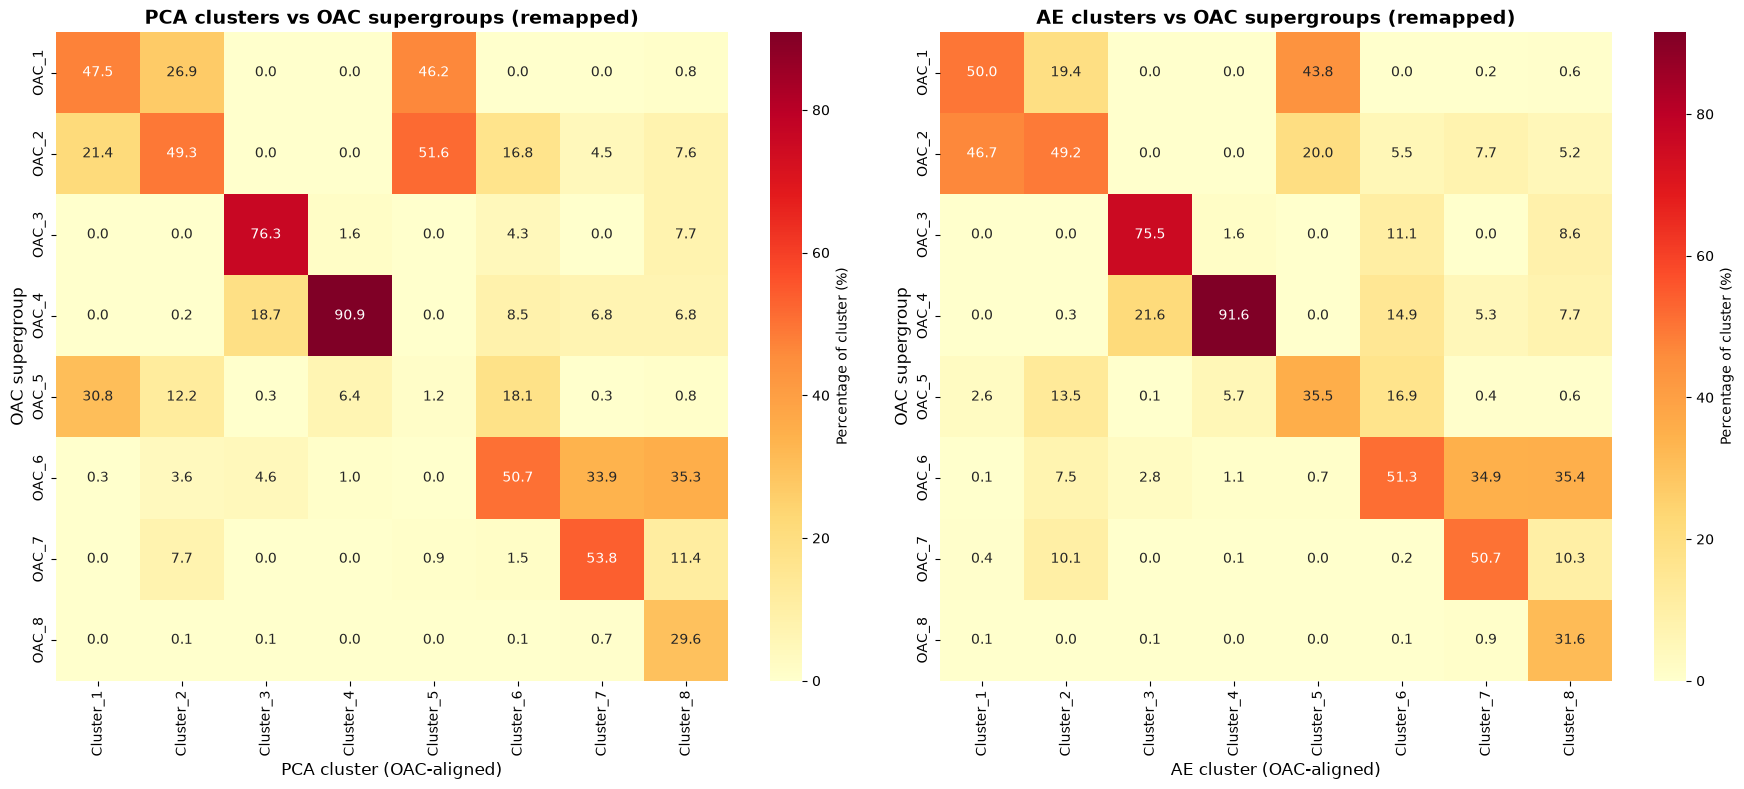


✓ Saved remapping tables and remapped overlap percentages to ./clustering_results/
⚠️  All subsequent cells will use OAC-aligned cluster IDs!


In [8]:
print("Computing cluster-to-OAC overlap matrices...\n")

def cluster_oac_overlap(cluster_labels, oac_labels, method_name, cluster_axis):
    """Return count and percentage matrices with clusters on the X-axis."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask]

    print(f"{method_name}: {valid_mask.sum():,} OAs with valid OAC labels")

    oac_ids = list(range(1, n_clusters + 1))
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_axis, fill_value=0)
    counts.index = [f'OAC_{oid}' for oid in counts.index]
    counts.columns = [f'Cluster_{cid}' for cid in counts.columns]

    percentages = counts.divide(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100
    percentages = percentages.fillna(0)

    return counts, percentages

original_cluster_axis = list(range(n_clusters))
pca_counts, pca_percent = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA', original_cluster_axis)
ae_counts, ae_percent = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE', original_cluster_axis)

print("\nPCA clusters → OAC distribution (% of cluster):")
print(pca_percent.round(1))
print("\nAE clusters → OAC distribution (% of cluster):")
print(ae_percent.round(1))

def greedy_one_to_one_mapping(counts_df):
    """Greedily assign each cluster to a unique OAC by highest overlap."""
    flattened = counts_df.stack().sort_values(ascending=False)
    cluster_mapping = {}
    used_oac = set()
    for (oac_label, cluster_label), value in flattened.items():
        cluster_id = int(cluster_label.split('_')[1])
        oac_id = int(oac_label.split('_')[1])
        if cluster_id not in cluster_mapping and oac_id not in used_oac:
            cluster_mapping[cluster_id] = oac_id
            used_oac.add(oac_id)
        if len(cluster_mapping) == counts_df.shape[1]:
            break

    remaining_clusters = sorted(set(range(counts_df.shape[1])) - set(cluster_mapping.keys()))
    remaining_oac = sorted(set(range(1, counts_df.shape[0] + 1)) - used_oac)
    for cluster_id, oac_id in zip(remaining_clusters, remaining_oac):
        cluster_mapping[cluster_id] = oac_id

    return cluster_mapping

pca_mapping = greedy_one_to_one_mapping(pca_counts)
ae_mapping = greedy_one_to_one_mapping(ae_counts)

print("\n" + "="*80)
print("Greedy one-to-one remapping (PCA clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(pca_mapping.keys()):
    oac_id = pca_mapping[cluster_id]
    overlap = int(pca_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(pca_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

print("\n" + "="*80)
print("Greedy one-to-one remapping (AE clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(ae_mapping.keys()):
    oac_id = ae_mapping[cluster_id]
    overlap = int(ae_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(ae_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

# Apply remapping to cluster assignments
pca_clusters_remapped = np.array([pca_mapping[c] for c in pca_clusters])
ae_clusters_remapped = np.array([ae_mapping[c] for c in ae_clusters])

# Update global state
clusters_df['pca_cluster'] = pca_clusters_remapped
clusters_df['ae_cluster'] = ae_clusters_remapped

if 'gdf' in locals():
    gdf['pca_cluster'] = pca_clusters_remapped
    gdf['ae_cluster'] = ae_clusters_remapped

pca_clusters = pca_clusters_remapped
ae_clusters = ae_clusters_remapped

# Recompute overlap matrices after remapping (clusters now 1..n_clusters)
remapped_cluster_axis = list(range(1, n_clusters + 1))
pca_counts_remap, pca_percent_remap = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA (remapped)', remapped_cluster_axis)
ae_counts_remap, ae_percent_remap = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE (remapped)', remapped_cluster_axis)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pca_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[0].set_title('PCA clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PCA cluster (OAC-aligned)', fontsize=12)
axes[0].set_ylabel('OAC supergroup', fontsize=12)

sns.heatmap(ae_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[1].set_title('AE clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AE cluster (OAC-aligned)', fontsize=12)
axes[1].set_ylabel('OAC supergroup', fontsize=12)

plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_oac_overlap_remapped_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

# Save mapping tables
pca_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': pca_mapping[cluster_id],
        'overlap_count': int(pca_counts.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(pca_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(pca_percent.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(pca_mapping.keys())
 ])
pca_mapping_df.to_csv(f"{results_dir}/pca_cluster_remapping_{target_dim}d.csv", index=False)

ae_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': ae_mapping[cluster_id],
        'overlap_count': int(ae_counts.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(ae_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(ae_percent.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(ae_mapping.keys())
 ])
ae_mapping_df.to_csv(f"{results_dir}/ae_cluster_remapping_{target_dim}d.csv", index=False)

# Save remapped percentage matrices (key results only)
pca_percent_remap.to_csv(f"{results_dir}/pca_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")
ae_percent_remap.to_csv(f"{results_dir}/ae_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")

print(f"\n✓ Saved remapping tables and remapped overlap percentages to {results_dir}")
print("⚠️  All subsequent cells will use OAC-aligned cluster IDs!")

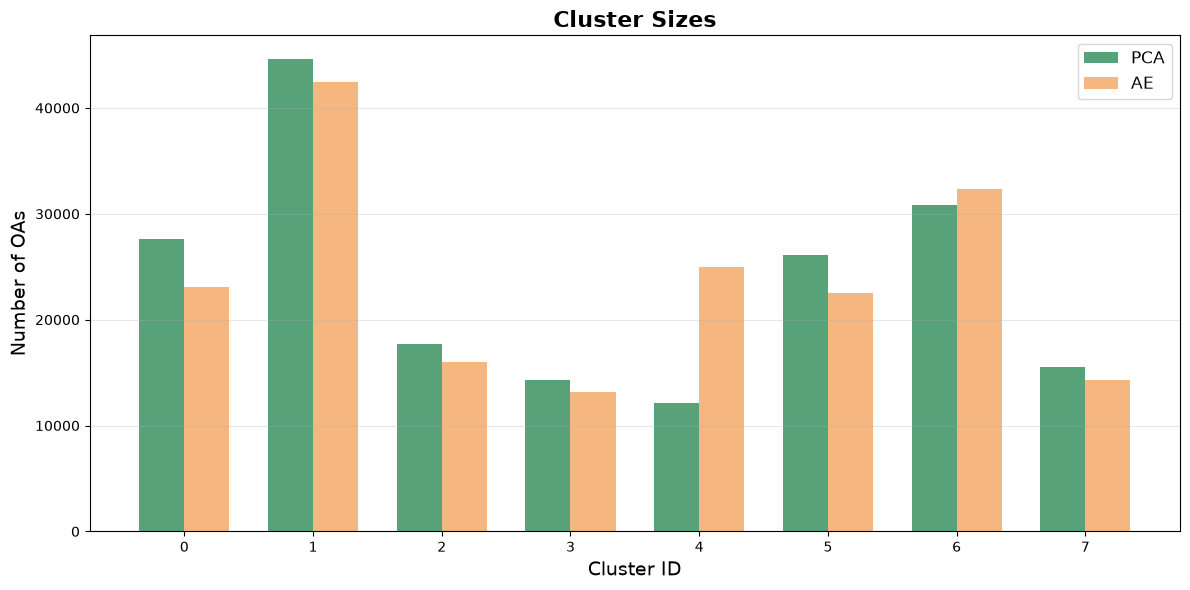

In [9]:
# Cluster size comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_clusters)
width = 0.35

pca_sizes = [np.sum(pca_clusters == i+1) for i in range(n_clusters)]
ae_sizes = [np.sum(ae_clusters == i+1) for i in range(n_clusters)]

ax.bar(x - width/2, pca_sizes, width, label='PCA', color='seagreen', alpha=0.8)
ax.bar(x + width/2, ae_sizes, width, label='AE', color='sandybrown', alpha=0.8)

ax.set_xlabel('Cluster ID', fontsize=14)
ax.set_ylabel('Number of OAs', fontsize=14)
ax.set_title('Cluster Sizes', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_sizes_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

## Maps

Loading geometries for mapping...


GeoDataFrame: (188880, 4)


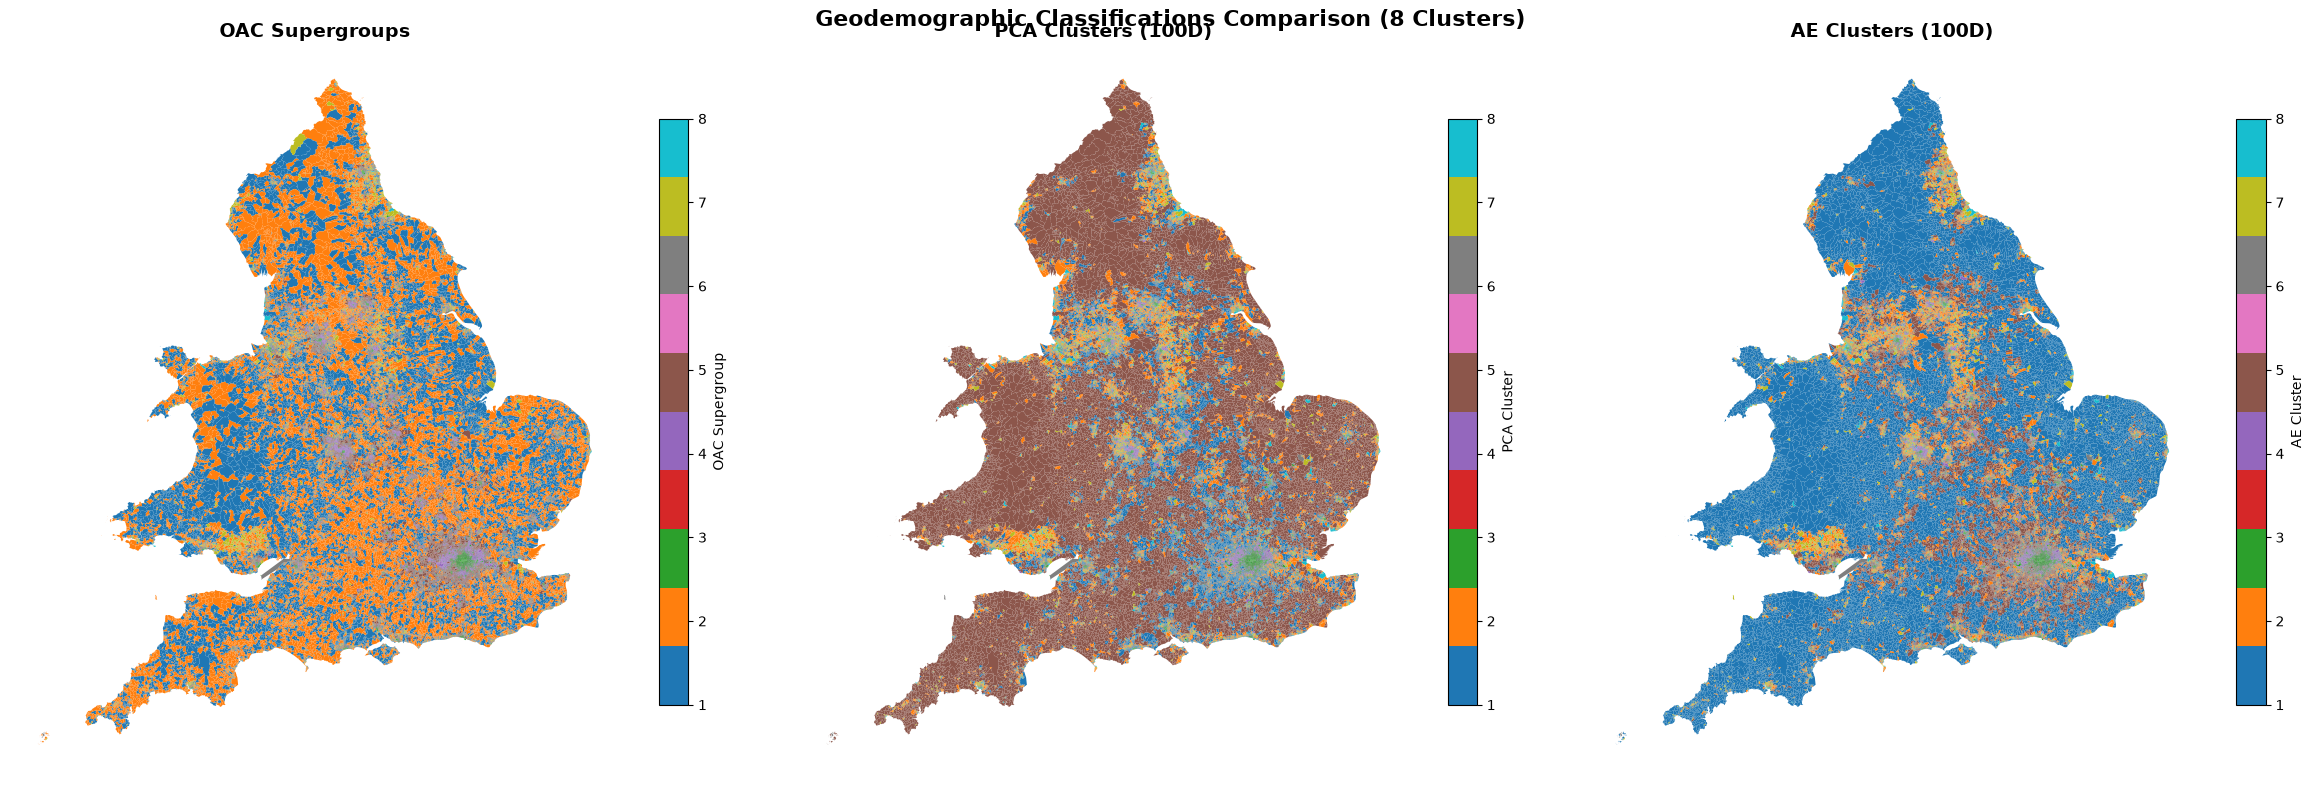

In [10]:
# Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file(geo_path)
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')

# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Create side-by-side maps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# OAC
gdf.plot(column='oac_supergroup', ax=axes[0], legend=True, 
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'OAC Supergroup', 'shrink': 0.8})
axes[0].set_title('OAC Supergroups', fontsize=14, fontweight='bold')
axes[0].axis('off')

# PCA
gdf.plot(column='pca_cluster', ax=axes[1], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
axes[1].set_title(f'PCA Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# AE
gdf.plot(column='ae_cluster', ax=axes[2], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
axes[2].set_title(f'AE Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'Geodemographic Classifications Comparison ({n_clusters} Clusters)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(f"{plots_dir}/classification_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

Creating regional zoom maps...
London: 29,687 OAs


Cornwall: 1,918 OAs


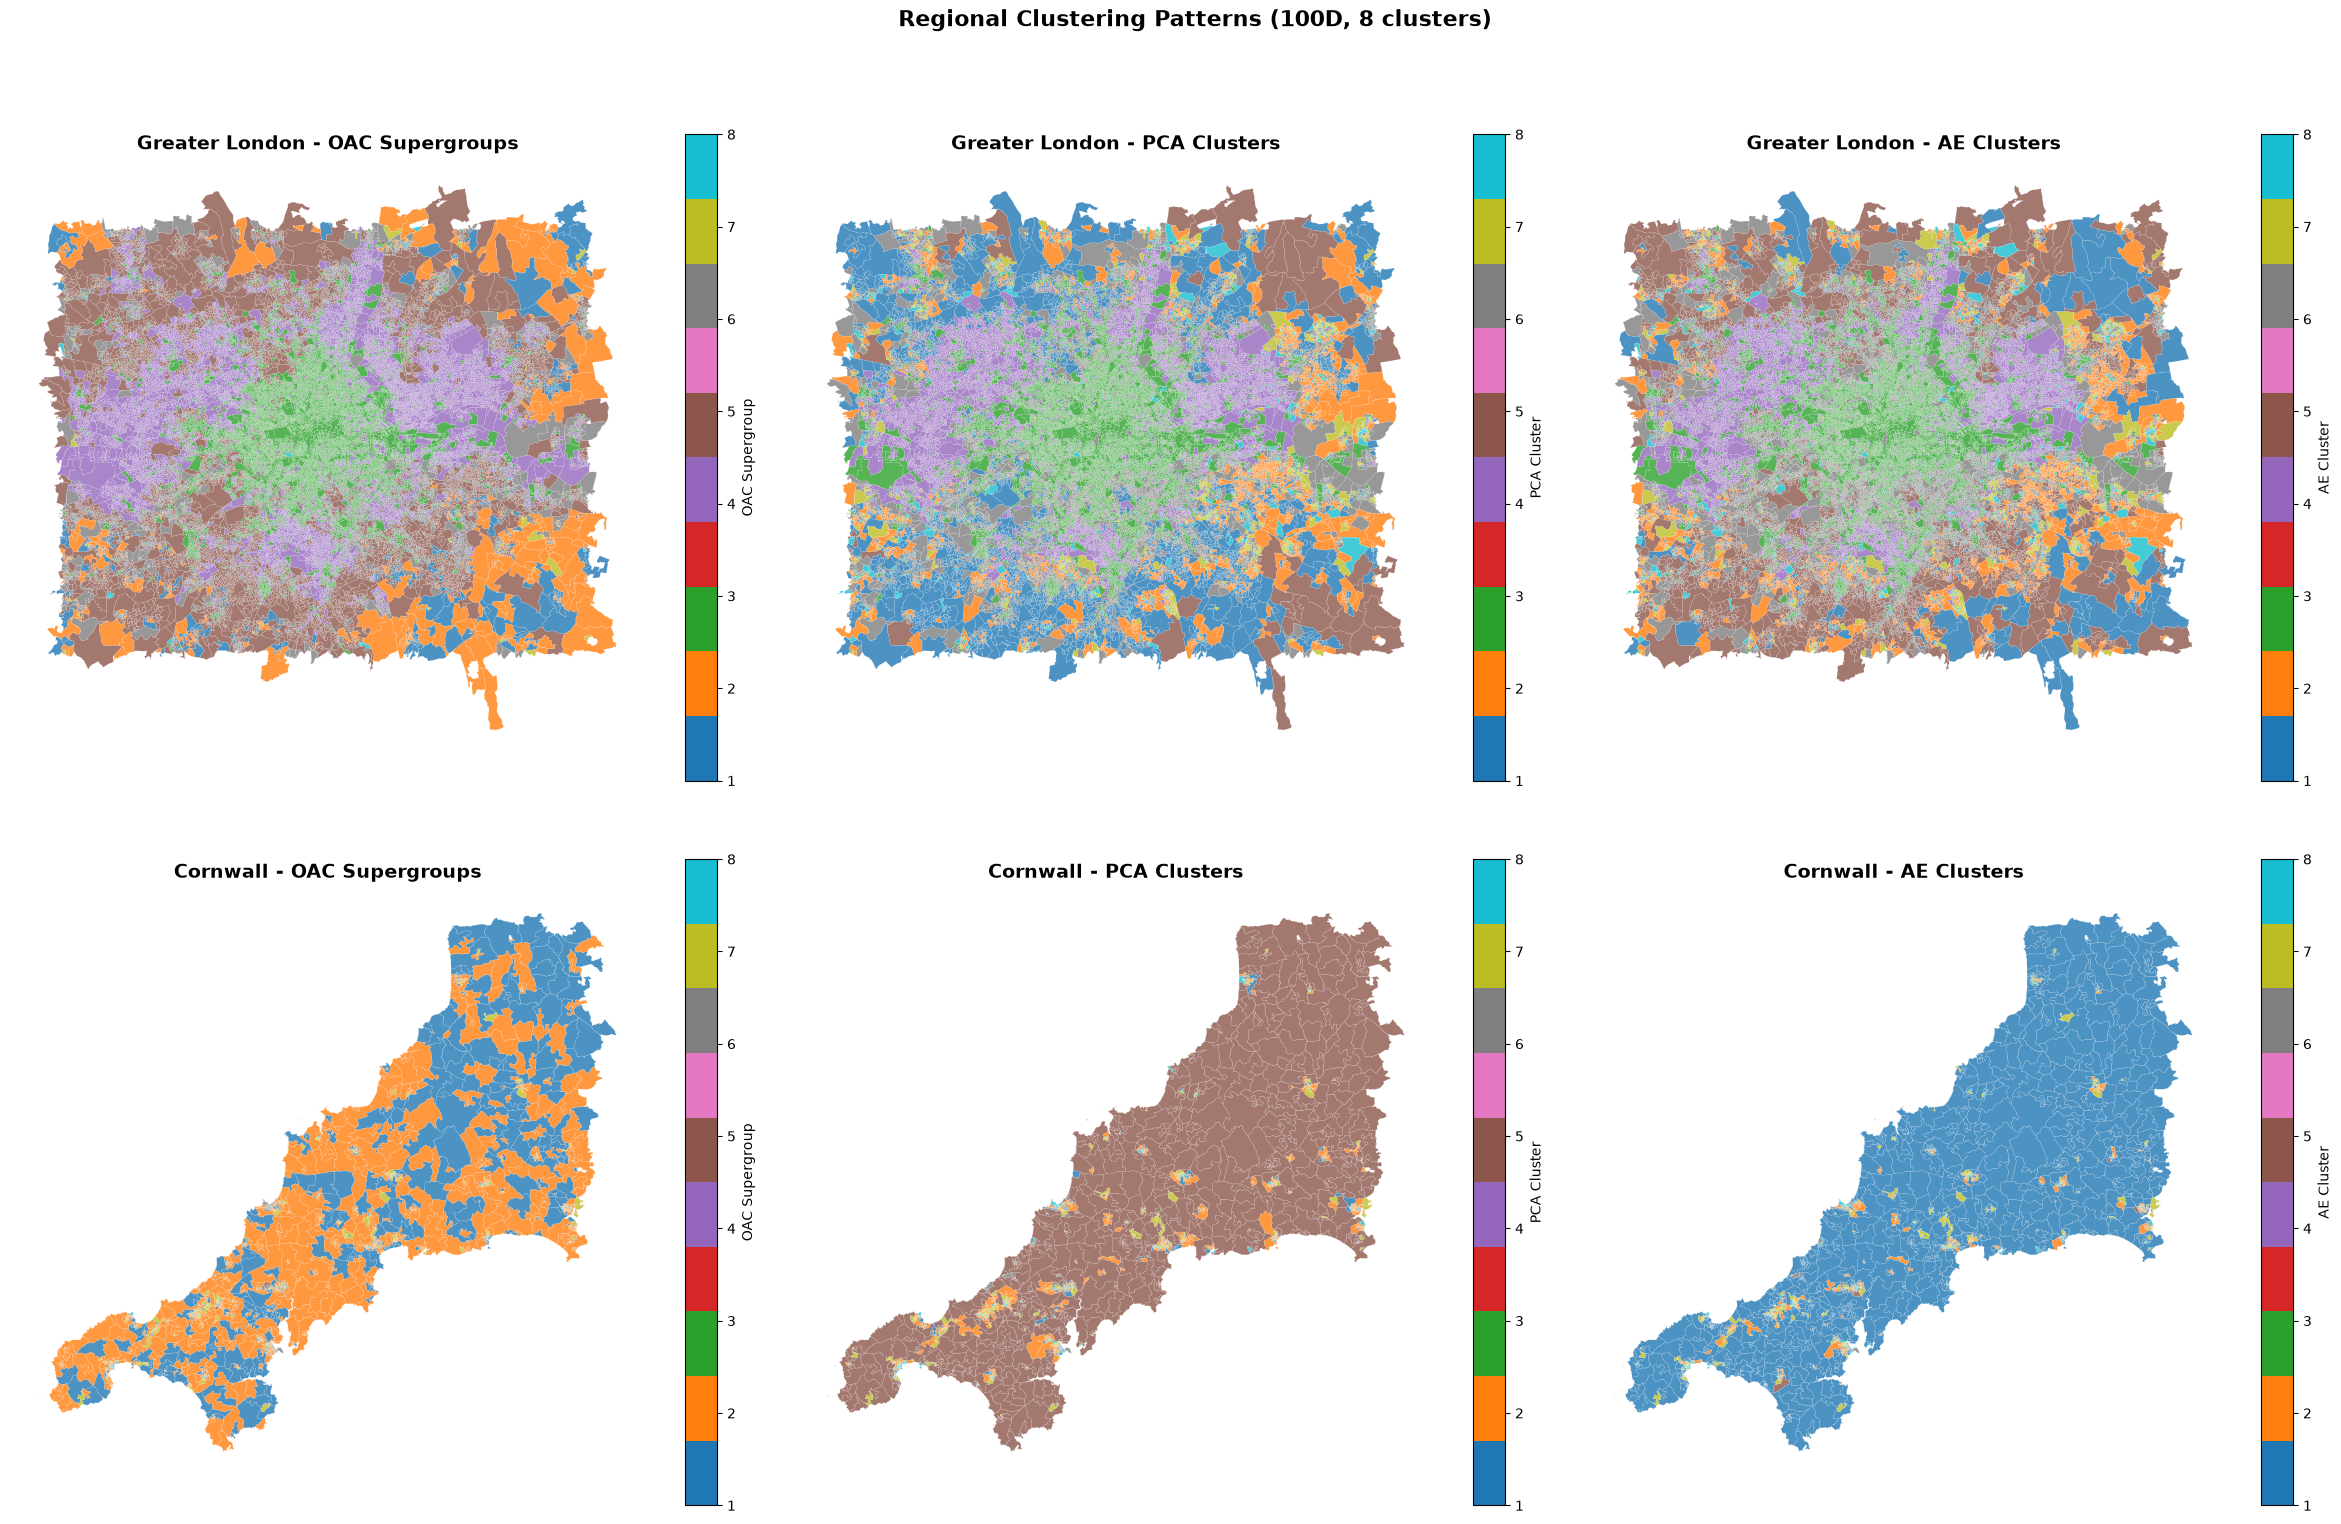


✓ Saved regional maps to ./plots/clustering_plots//regional_maps_100d.png


In [11]:
# Regional zoom maps for London and Cornwall
print("Creating regional zoom maps...")

# Define bounding boxes (approximate)
regions = {
    'London': {
        'bounds': {'minx': -0.5, 'maxx': 0.3, 'miny': 51.3, 'maxy': 51.7},
        'title': 'Greater London'
    },
    'Cornwall': {
        'bounds': {'minx': -5.7, 'maxx': -4.2, 'miny': 50.0, 'maxy': 50.9},
        'title': 'Cornwall'
    }
}

# Create figure with 2 rows x 3 columns (OAC, PCA, AE)
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for row_idx, (region_name, region_info) in enumerate(regions.items()):
    # Filter to region using bounding box
    bounds = region_info['bounds']
    region_gdf = gdf.cx[bounds['minx']:bounds['maxx'], bounds['miny']:bounds['maxy']]

    print(f"{region_name}: {len(region_gdf):,} OAs")

    # OAC supergroups
    region_gdf.plot(column='oac_supergroup', ax=axes[row_idx, 0], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'OAC Supergroup', 'shrink': 0.8})
    axes[row_idx, 0].set_title(f'{region_info["title"]} - OAC Supergroups',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # PCA clusters
    region_gdf.plot(column='pca_cluster', ax=axes[row_idx, 1], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
    axes[row_idx, 1].set_title(f'{region_info["title"]} - PCA Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 1].axis('off')

    # AE clusters
    region_gdf.plot(column='ae_cluster', ax=axes[row_idx, 2], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
    axes[row_idx, 2].set_title(f'{region_info["title"]} - AE Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 2].axis('off')

plt.suptitle(f'Regional Clustering Patterns ({target_dim}D, {n_clusters} clusters)',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{plots_dir}/regional_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved regional maps to {plots_dir}/regional_maps_{target_dim}d.png")

## Summary

In [12]:
# Load quality metrics if not in memory
if 'quality_metrics' not in locals():
    quality_metrics = pd.read_csv(f"{results_dir}/quality_metrics_{target_dim}d.csv")
    wssc_pca = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['PCA'].values[0]
    wssc_ae = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['AE'].values[0]
    silhouette_pca = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['PCA'].values[0]
    silhouette_ae = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['AE'].values[0]
    db_pca = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['PCA'].values[0]
    db_ae = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['AE'].values[0]
    print(f"✓ Loaded quality metrics from {results_dir}")

print("="*80)
print(f"GEODEMOGRAPHIC CLUSTERING SUMMARY ({target_dim}D, {n_clusters} clusters)")
print("="*80)

print("\n1. CLUSTER QUALITY METRICS:")
print("-"*80)
print(quality_metrics.to_string(index=False))

print("\n2. COMPARISON TO OAC:")
print("-"*80)
print(f"Adjusted Rand Index:")
print(f"  PCA:  {ari_pca:.4f}")
print(f"  AE:   {ari_ae:.4f}")
print(f"\nV-Measure:")
print(f"  PCA:  {v_pca:.4f}")
print(f"  AE:   {v_ae:.4f}")

print("\n3. CLUSTER SIZES:")
print("-"*80)
size_comparison = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA': pca_sizes,
    'AE': ae_sizes
})
print(size_comparison.to_string(index=False))

print("\n" + "="*80)
print(f"Plots saved to: {plots_dir}")
print(f"Data saved to: {results_dir}")
print("="*80)

print("\nKey Findings:")
if wssc_ae < wssc_pca:
    print(f"- AE has lower within-cluster variance (WSSC: {wssc_ae:.2f} vs {wssc_pca:.2f})")
else:
    print(f"- PCA has lower within-cluster variance (WSSC: {wssc_pca:.2f} vs {wssc_ae:.2f})")

if silhouette_ae > silhouette_pca:
    print(f"- AE produces better cluster separation (Silhouette: {silhouette_ae:.4f} vs {silhouette_pca:.4f})")
else:
    print(f"- PCA produces better cluster separation (Silhouette: {silhouette_pca:.4f} vs {silhouette_ae:.4f})")

if db_ae < db_pca:
    print(f"- AE clusters are more distinct (Davies-Bouldin: {db_ae:.4f} vs {db_pca:.4f})")
else:
    print(f"- PCA clusters are more distinct (Davies-Bouldin: {db_pca:.4f} vs {db_ae:.4f})")

print(f"\n- Both methods show {'low' if max(ari_pca, ari_ae) < 0.3 else 'moderate'} agreement with OAC")
print("  → Expected: different methods capture different demographic structure")

GEODEMOGRAPHIC CLUSTERING SUMMARY (100D, 8 clusters)

1. CLUSTER QUALITY METRICS:
--------------------------------------------------------------------------------
           Metric           PCA            AE Better Winner
     WSSC/Inertia 219351.760597 137297.429810  Lower     AE
 Silhouette Score      0.125079      0.111544 Higher    PCA
   Davies-Bouldin      1.892288      2.000545  Lower    PCA
Calinski-Harabasz  26125.498177  27293.318670 Higher     AE
         WCSS/TSS      0.508061      0.497129  Lower     AE
         BCSS/TSS      0.491939      0.502871 Higher     AE

2. COMPARISON TO OAC:
--------------------------------------------------------------------------------
Adjusted Rand Index:
  PCA:  0.2816
  AE:   0.2688

V-Measure:
  PCA:  0.4376
  AE:   0.4311

3. CLUSTER SIZES:
--------------------------------------------------------------------------------
 Cluster   PCA    AE
       0 27632 23120
       1 44631 42422
       2 17702 16034
       3 14330 13144
       4 12093 